## HW3 | DL | RNN

In [1]:
!pip -q install torch scikit-learn matplotlib seaborn pandas numpy 

In [2]:
import re
import time

from collections import Counter
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split

In [3]:
URL = "https://archive.ics.uci.edu/static/public/461/drug+review+dataset+druglib+com.zip"

def load_druglib():
    raw = urlopen(URL, timeout=60).read()
    z = ZipFile(BytesIO(raw))
    names = z.namelist()
    print("Files", names)
    def read_tsv(key):
        fn = [n for n in names if key in n.lower() and n.lower().endswith(".tsv")][0]
        return pd.read_csv(z.open(fn), sep="\t", index_col=0)
    return read_tsv("train"), read_tsv("test")

train_df, test_df = load_druglib()
print("train:", train_df.shape, "| test:", test_df.shape)
train_df.head(3)

Files ['drugLibTest_raw.tsv', 'drugLibTrain_raw.tsv']
train: (3107, 8) | test: (1036, 8)


,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...


### Constants

In [4]:
SEED = 42
DTYPE = np.float32

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_ID = 0
UNK_ID = 1

MAX_VOCAB_SIZE = 8_000
MIN_TOKEN_FREQUENCY = 2

RATING_MAX_SEQUENCE_LENGTH = 120
EFFECTIVENESS_MAX_SEQUENCE_LENGTH = 80

EMBEDDING_DIM = 32
HIDDEN_DIM = 32

BATCH_SIZE = 64

LEARNING_RATE = 1e-3
MAX_GRADIENT_NORM = 5.0

np.random.seed(SEED)

### Text preprocessing
#### Tokenization

In [5]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|\d+(?:\.\d+)?")

def tokenize(text):
    text = str(text).lower()
    return TOKEN_PATTERN.findall(text)

example_text = "The drug wasn't effective after 10 days."

print(tokenize(example_text))

['the', 'drug', "wasn't", 'effective', 'after', '10', 'days']


#### Text-length statistics

In [6]:
def show_text_length_statistics(texts):
    lengths = np.array([len(tokenize(text)) for text in texts])

    statistics = {
        "Minimum": lengths.min(),
        "Median": np.median(lengths),
        "90th percentile": np.percentile(lengths, 90),
        "95th percentile": np.percentile(lengths, 95),
        "99th percentile": np.percentile(lengths, 99),
        "Maximum": lengths.max()
    }

    statistics_df = pd.DataFrame(
        statistics.items(),
        columns=["Statistic", "Number of tokens"]
    )

    display(statistics_df)

#### Vocabulary

In [7]:
def build_vocabulary(texts, max_vocabulary_size=MAX_VOCAB_SIZE, min_frequency=MIN_TOKEN_FREQUENCY):
    token_counter = Counter()

    for text in texts:
        token_counter.update(tokenize(text))

    vocabulary = {
        PAD_TOKEN: PAD_ID,
        UNK_TOKEN: UNK_ID
    }

    for token, frequency in token_counter.most_common():
        if frequency < min_frequency:
            continue

        if len(vocabulary) >= max_vocabulary_size:
            break

        vocabulary[token] = len(vocabulary)

    return vocabulary

#### Convert text to token ids

In [8]:
def encode_texts(texts, vocabulary, max_sequence_length):
    encoded_texts = np.full((len(texts), max_sequence_length), PAD_ID, dtype=np.int32)

    for row_index, text in enumerate(texts):
        tokens = tokenize(text)[:max_sequence_length]
        token_ids = [vocabulary.get(token, UNK_ID) for token in tokens]

        encoded_texts[row_index, :len(token_ids)] = token_ids

    return encoded_texts

#### Text prep pipe

In [9]:
def prepare_text_data(train_texts, test_texts, max_sequence_length, max_vocabulary_size=MAX_VOCAB_SIZE):
    train_texts = pd.Series(train_texts).fillna("").astype(str).tolist()
    test_texts = pd.Series(test_texts).fillna("").astype(str).tolist()

    vocabulary = build_vocabulary(
        train_texts,
        max_vocabulary_size=max_vocabulary_size
    )

    X_train = encode_texts(train_texts, vocabulary, max_sequence_length)
    X_test = encode_texts(test_texts, vocabulary, max_sequence_length)

    print("Vocabulary size:", len(vocabulary))
    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    return X_train, X_test, vocabulary

### Label processing

In [10]:
def create_label_mapping(labels, class_order=None):
    observed_classes = list(pd.Series(labels).dropna().unique())

    if class_order is None:
        classes = sorted(observed_classes)
    else:
        classes = list(class_order)

        if set(classes) != set(observed_classes):
            raise ValueError(
                "Specified classes do not match the observed classes.\n"
                f"Specified: {classes}\n"
                f"Observed: {sorted(observed_classes)}"
            )

    label_to_id = {
        label: class_id
        for class_id, label in enumerate(classes)
    }

    id_to_label = {
        class_id: label
        for label, class_id in label_to_id.items()
    }

    return classes, label_to_id, id_to_label

def encode_labels(labels, label_to_id):
    encoded_labels = pd.Series(labels).map(label_to_id)

    if encoded_labels.isna().any():
        unknown_labels = pd.Series(labels)[encoded_labels.isna()].unique().tolist()
        raise ValueError(f"Unknown labels: {unknown_labels}")

    return encoded_labels.to_numpy(dtype=np.int64)

### Class weights

In [67]:
def calculate_class_weights(labels, number_of_classes):
    class_counts = np.bincount(labels, minlength=number_of_classes).astype(DTYPE)

    if np.any(class_counts == 0):
        raise ValueError("Every class must contain at least one training example.")

    class_weights = len(labels) / (number_of_classes * class_counts)
    class_weights = np.sqrt(class_weights)
    class_weights /= class_weights.mean()

    return class_weights.astype(DTYPE)


def show_class_distribution(labels, class_names, title):
    class_counts = np.bincount(labels, minlength=len(class_names))

    distribution = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "count": class_counts,
        "percentage": class_counts / class_counts.sum() * 100
    })

    print(title)

    display(distribution)

### Common maths funcs

In [12]:
def sigmoid(x):
    x = np.clip(x, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-x))


def softmax(logits):
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exponential_values = np.exp(shifted_logits)

    return exponential_values / np.sum(exponential_values, axis=1, keepdims=True)
    

def xavier_initialization(random_generator, input_size, output_size):
    limit = np.sqrt(6.0 / (input_size + output_size))
    weights = random_generator.uniform(-limit, limit, size=(input_size, output_size))

    return weights.astype(DTYPE)

### Models
#### Vanilla RNN

$h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h)$

In [13]:
class RNNLayer:
    def __init__(self, input_dim, hidden_dim, random_generator):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.params = {
            "W_xh": xavier_initialization(random_generator, input_dim, hidden_dim),
            "W_hh": xavier_initialization(random_generator, hidden_dim, hidden_dim),
            "b_h": np.zeros(hidden_dim, dtype=DTYPE)
        }

        self.grads = {
            name: np.zeros_like(value)
            for name, value in self.params.items()
        }

        self.cache = None

    def zero_grad(self):
        for gradient in self.grads.values():
            gradient.fill(0.0)

    def forward(self, X, mask):
        batch_size, sequence_length, _ = X.shape

        hidden_states = np.zeros((batch_size, sequence_length, self.hidden_dim), dtype=DTYPE)
        previous_hidden = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)

        cache = []

        for timestep in range(sequence_length):
            x_t = X[:, timestep, :]
            timestep_mask = mask[:, timestep][:, None]

            hidden_linear = (
                x_t @ self.params["W_xh"]
                + previous_hidden @ self.params["W_hh"]
                + self.params["b_h"]
            )

            candidate_hidden = np.tanh(hidden_linear)
            current_hidden = timestep_mask * candidate_hidden + (1.0 - timestep_mask) * previous_hidden

            hidden_states[:, timestep, :] = current_hidden

            cache.append((x_t, previous_hidden, candidate_hidden, timestep_mask))

            previous_hidden = current_hidden

        self.cache = cache

        return hidden_states

    def backward(self, hidden_gradients):
        batch_size, sequence_length, _ = hidden_gradients.shape

        input_gradients = np.zeros((batch_size, sequence_length, self.input_dim), dtype=DTYPE)
        next_hidden_gradient = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)

        for timestep in reversed(range(sequence_length)):
            x_t, previous_hidden, candidate_hidden, timestep_mask = self.cache[timestep]

            hidden_gradient = hidden_gradients[:, timestep, :] + next_hidden_gradient
            candidate_gradient = hidden_gradient * timestep_mask

            previous_hidden_gradient = hidden_gradient * (1.0 - timestep_mask)
            hidden_linear_gradient = candidate_gradient * (1.0 - candidate_hidden ** 2)

            self.grads["W_xh"] += x_t.T @ hidden_linear_gradient
            self.grads["W_hh"] += previous_hidden.T @ hidden_linear_gradient
            self.grads["b_h"] += np.sum(hidden_linear_gradient, axis=0)

            input_gradients[:, timestep, :] = hidden_linear_gradient @ self.params["W_xh"].T
            next_hidden_gradient = previous_hidden_gradient + hidden_linear_gradient @ self.params["W_hh"].T

        return input_gradients

#### GRU
$z_t = \sigma(x_t W_{xz} + h_{t-1} W_{hz} + b_z)$

$r_t = \sigma(x_t W_{xr} + h_{t-1} W_{hr} + b_r)$

$\tilde{h}_t = \tanh \left( x_t W_{xn} + (r_t \odot h_{t-1}) W_{hn} + b_n \right)$

$h_t = (1 - z_t) \odot \tilde{h}_t + z_t \odot h_{t-1}$

In [14]:
class GRULayer:
    def __init__(self, input_dim, hidden_dim, random_generator):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.params = {
            "W_xz": xavier_initialization(random_generator, input_dim, hidden_dim),
            "W_hz": xavier_initialization(random_generator, hidden_dim, hidden_dim),
            "b_z": np.zeros(hidden_dim, dtype=DTYPE),

            "W_xr": xavier_initialization(random_generator, input_dim, hidden_dim),
            "W_hr": xavier_initialization(random_generator, hidden_dim, hidden_dim),
            "b_r": np.zeros(hidden_dim, dtype=DTYPE),

            "W_xn": xavier_initialization(random_generator, input_dim, hidden_dim),
            "W_hn": xavier_initialization(random_generator, hidden_dim, hidden_dim),
            "b_n": np.zeros(hidden_dim, dtype=DTYPE)
        }

        self.grads = {
            name: np.zeros_like(value)
            for name, value in self.params.items()
        }

        self.cache = None

    def zero_grad(self):
        for gradient in self.grads.values():
            gradient.fill(0.0)

    def forward(self, X, mask):
        batch_size, sequence_length, _ = X.shape

        hidden_states = np.zeros((batch_size, sequence_length, self.hidden_dim), dtype=DTYPE)
        previous_hidden = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)

        cache = []

        for timestep in range(sequence_length):
            x_t = X[:, timestep, :]
            timestep_mask = mask[:, timestep][:, None]

            update_gate = sigmoid(
                x_t @ self.params["W_xz"]
                + previous_hidden @ self.params["W_hz"]
                + self.params["b_z"]
            )

            reset_gate = sigmoid(
                x_t @ self.params["W_xr"]
                + previous_hidden @ self.params["W_hr"]
                + self.params["b_r"]
            )

            reset_hidden = reset_gate * previous_hidden

            candidate_hidden = np.tanh(
                x_t @ self.params["W_xn"]
                + reset_hidden @ self.params["W_hn"]
                + self.params["b_n"]
            )

            unmasked_hidden = (1.0 - update_gate) * candidate_hidden + update_gate * previous_hidden
            current_hidden = timestep_mask * unmasked_hidden + (1.0 - timestep_mask) * previous_hidden

            hidden_states[:, timestep, :] = current_hidden

            cache.append((
                x_t,
                previous_hidden,
                update_gate,
                reset_gate,
                reset_hidden,
                candidate_hidden,
                timestep_mask
            ))

            previous_hidden = current_hidden

        self.cache = cache

        return hidden_states

    def backward(self, hidden_gradients):
        batch_size, sequence_length, _ = hidden_gradients.shape

        input_gradients = np.zeros((batch_size, sequence_length, self.input_dim), dtype=DTYPE)
        next_hidden_gradient = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)

        for timestep in reversed(range(sequence_length)):
            (
                x_t,
                previous_hidden,
                update_gate,
                reset_gate,
                reset_hidden,
                candidate_hidden,
                timestep_mask
            ) = self.cache[timestep]

            hidden_gradient = hidden_gradients[:, timestep, :] + next_hidden_gradient
            unmasked_gradient = hidden_gradient * timestep_mask

            previous_hidden_gradient = hidden_gradient * (1.0 - timestep_mask)
            candidate_gradient = unmasked_gradient * (1.0 - update_gate)

            update_gradient = unmasked_gradient * (previous_hidden - candidate_hidden)
            previous_hidden_gradient += unmasked_gradient * update_gate

            candidate_linear_gradient = candidate_gradient * (1.0 - candidate_hidden ** 2)

            self.grads["W_xn"] += x_t.T @ candidate_linear_gradient
            self.grads["W_hn"] += reset_hidden.T @ candidate_linear_gradient
            self.grads["b_n"] += np.sum(candidate_linear_gradient, axis=0)

            current_input_gradient = candidate_linear_gradient @ self.params["W_xn"].T
            reset_hidden_gradient = candidate_linear_gradient @ self.params["W_hn"].T

            reset_gradient = reset_hidden_gradient * previous_hidden

            previous_hidden_gradient += reset_hidden_gradient * reset_gate

            reset_linear_gradient = reset_gradient * reset_gate * (1.0 - reset_gate)

            self.grads["W_xr"] += x_t.T @ reset_linear_gradient
            self.grads["W_hr"] += previous_hidden.T @ reset_linear_gradient
            self.grads["b_r"] += np.sum(reset_linear_gradient, axis=0)

            current_input_gradient += reset_linear_gradient @ self.params["W_xr"].T
            previous_hidden_gradient += reset_linear_gradient @ self.params["W_hr"].T

            update_linear_gradient = update_gradient * update_gate * (1.0 - update_gate)

            self.grads["W_xz"] += x_t.T @ update_linear_gradient
            self.grads["W_hz"] += previous_hidden.T @ update_linear_gradient
            self.grads["b_z"] += np.sum(update_linear_gradient, axis=0)

            current_input_gradient += update_linear_gradient @ self.params["W_xz"].T
            previous_hidden_gradient += update_linear_gradient @ self.params["W_hz"].T

            input_gradients[:, timestep, :] = current_input_gradient

            next_hidden_gradient = previous_hidden_gradient

        return input_gradients

#### LSTM

$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$

$h_t = o_t \odot \tanh(c_t)$

In [15]:
class LSTMLayer:
    def __init__(self, input_dim, hidden_dim, random_generator):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.params = {
            "W_x": xavier_initialization(random_generator, input_dim, 4 * hidden_dim),
            "W_h": xavier_initialization(random_generator, hidden_dim, 4 * hidden_dim),
            "b": np.zeros(4 * hidden_dim, dtype=DTYPE)
        }

        self.params["b"][hidden_dim:2 * hidden_dim] = 1.0

        self.grads = {
            name: np.zeros_like(value)
            for name, value in self.params.items()
        }

        self.cache = None

    def zero_grad(self):
        for gradient in self.grads.values():
            gradient.fill(0.0)

    def forward(self, X, mask):
        batch_size, sequence_length, _ = X.shape

        hidden_states = np.zeros((batch_size, sequence_length, self.hidden_dim), dtype=DTYPE)

        previous_hidden = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)
        previous_cell = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)

        cache = []

        for timestep in range(sequence_length):
            x_t = X[:, timestep, :]
            timestep_mask = mask[:, timestep][:, None]

            gates = x_t @ self.params["W_x"] + previous_hidden @ self.params["W_h"] + self.params["b"]

            input_gate = sigmoid(gates[:, :self.hidden_dim])
            forget_gate = sigmoid(gates[:, self.hidden_dim:2 * self.hidden_dim])
            output_gate = sigmoid(gates[:, 2 * self.hidden_dim:3 * self.hidden_dim])

            candidate_cell = np.tanh(gates[:, 3 * self.hidden_dim:])

            unmasked_cell = forget_gate * previous_cell + input_gate * candidate_cell
            unmasked_hidden = output_gate * np.tanh(unmasked_cell)

            current_cell = timestep_mask * unmasked_cell + (1.0 - timestep_mask) * previous_cell
            current_hidden = timestep_mask * unmasked_hidden + (1.0 - timestep_mask) * previous_hidden

            hidden_states[:, timestep, :] = current_hidden

            cache.append((
                x_t,
                previous_hidden,
                previous_cell,
                input_gate,
                forget_gate,
                output_gate,
                candidate_cell,
                unmasked_cell,
                timestep_mask
            ))

            previous_hidden = current_hidden
            previous_cell = current_cell

        self.cache = cache

        return hidden_states

    def backward(self, hidden_gradients):
        batch_size, sequence_length, _ = hidden_gradients.shape

        input_gradients = np.zeros((batch_size, sequence_length, self.input_dim), dtype=DTYPE)

        next_hidden_gradient = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)
        next_cell_gradient = np.zeros((batch_size, self.hidden_dim), dtype=DTYPE)

        for timestep in reversed(range(sequence_length)):
            (
                x_t,
                previous_hidden,
                previous_cell,
                input_gate,
                forget_gate,
                output_gate,
                candidate_cell,
                unmasked_cell,
                timestep_mask
            ) = self.cache[timestep]

            hidden_gradient = hidden_gradients[:, timestep, :] + next_hidden_gradient

            unmasked_hidden_gradient = hidden_gradient * timestep_mask
            previous_hidden_gradient = hidden_gradient * (1.0 - timestep_mask)

            unmasked_cell_gradient = next_cell_gradient * timestep_mask
            previous_cell_gradient = next_cell_gradient * (1.0 - timestep_mask)

            tanh_cell = np.tanh(unmasked_cell)

            output_gradient = unmasked_hidden_gradient * tanh_cell

            unmasked_cell_gradient += unmasked_hidden_gradient * output_gate * (1.0 - tanh_cell ** 2)

            forget_gradient = unmasked_cell_gradient * previous_cell
            input_gradient = unmasked_cell_gradient * candidate_cell
            candidate_gradient = unmasked_cell_gradient * input_gate

            previous_cell_gradient += unmasked_cell_gradient * forget_gate

            input_linear_gradient = input_gradient * input_gate * (1.0 - input_gate)
            forget_linear_gradient = forget_gradient * forget_gate * (1.0 - forget_gate)
            output_linear_gradient = output_gradient * output_gate * (1.0 - output_gate)

            candidate_linear_gradient = candidate_gradient * (1.0 - candidate_cell ** 2)

            gates_gradient = np.concatenate(
                (
                    input_linear_gradient,
                    forget_linear_gradient,
                    output_linear_gradient,
                    candidate_linear_gradient
                ),
                axis=1
            )

            self.grads["W_x"] += x_t.T @ gates_gradient
            self.grads["W_h"] += previous_hidden.T @ gates_gradient
            self.grads["b"] += np.sum(gates_gradient, axis=0)

            input_gradients[:, timestep, :] = gates_gradient @ self.params["W_x"].T

            next_hidden_gradient = previous_hidden_gradient + gates_gradient @ self.params["W_h"].T

            next_cell_gradient = previous_cell_gradient

        return input_gradients

#### General sequence classifier

It is used for all architectures(RNN, GRU and LSTM) as well as all predictions (for rating and effectiveness)

In [16]:
class SequenceClassifier:
    def __init__(self, vocabulary_size, embedding_dim, hidden_dim, number_of_classes, cell_type, number_of_layers, seed=SEED):
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.number_of_classes = number_of_classes

        self.cell_type = cell_type.lower()
        self.number_of_layers = number_of_layers

        self.random_generator = np.random.default_rng(seed)

        embedding = self.random_generator.normal(
            0.0,
            0.05,
            size=(vocabulary_size, embedding_dim)
        ).astype(DTYPE)

        embedding[PAD_ID] = 0.0

        self.params = {
            "embedding": embedding,
            "W_output": xavier_initialization(
                self.random_generator,
                hidden_dim,
                number_of_classes
            ),
            "b_output": np.zeros(number_of_classes, dtype=DTYPE)
        }

        self.grads = {
            name: np.zeros_like(value)
            for name, value in self.params.items()
        }

        layer_classes = {
            "rnn": RNNLayer,
            "gru": GRULayer,
            "lstm": LSTMLayer
        }

        if self.cell_type not in layer_classes:
            raise ValueError("cell_type must be 'rnn', 'gru', or 'lstm'.")

        layer_class = layer_classes[self.cell_type]

        self.layers = []

        current_input_dim = embedding_dim

        for _ in range(number_of_layers):
            layer = layer_class(current_input_dim, hidden_dim, self.random_generator)

            self.layers.append(layer)

            current_input_dim = hidden_dim

        self.last_token_ids = None
        self.last_hidden_sequence = None

    def zero_grad(self):
        for gradient in self.grads.values():
            gradient.fill(0.0)

        for layer in self.layers:
            layer.zero_grad()

    def forward(self, token_ids):
        mask = (token_ids != PAD_ID).astype(DTYPE)

        sequence = self.params["embedding"][token_ids]

        for layer in self.layers:
            sequence = layer.forward(sequence, mask)

        final_hidden = sequence[:, -1, :]

        logits = (
            final_hidden @ self.params["W_output"]
            + self.params["b_output"]
        )

        probabilities = softmax(logits)

        self.last_token_ids = token_ids
        self.last_hidden_sequence = sequence

        return probabilities

    def loss_and_backward(self, token_ids, targets, class_weights):
        self.zero_grad()

        probabilities = self.forward(token_ids)

        sample_weights = class_weights[targets]

        target_probabilities = probabilities[
            np.arange(len(targets)),
            targets
        ]

        individual_losses = -np.log(target_probabilities + 1e-12)

        loss_numerator = np.sum(sample_weights * individual_losses)
        loss_denominator = np.sum(sample_weights)

        loss = loss_numerator / loss_denominator

        logits_gradient = probabilities.copy()

        logits_gradient[
            np.arange(len(targets)),
            targets
        ] -= 1.0

        logits_gradient *= sample_weights[:, None] / loss_denominator

        final_hidden = self.last_hidden_sequence[:, -1, :]

        self.grads["W_output"] += final_hidden.T @ logits_gradient
        self.grads["b_output"] += np.sum(logits_gradient, axis=0)

        sequence_gradient = np.zeros_like(self.last_hidden_sequence)

        sequence_gradient[:, -1, :] = (
            logits_gradient
            @ self.params["W_output"].T
        )

        for layer in reversed(self.layers):
            sequence_gradient = layer.backward(sequence_gradient)

        np.add.at(
            self.grads["embedding"],
            self.last_token_ids.reshape(-1),
            sequence_gradient.reshape(-1, self.embedding_dim)
        )

        self.grads["embedding"][PAD_ID] = 0.0

        return loss, probabilities, loss_numerator, loss_denominator

    def named_parameters(self):
        parameters = dict(self.params)

        for layer_index, layer in enumerate(self.layers):
            for name, value in layer.params.items():
                parameters[f"layer_{layer_index}.{name}"] = value

        return parameters

    def named_gradients(self):
        gradients = dict(self.grads)

        for layer_index, layer in enumerate(self.layers):
            for name, value in layer.grads.items():
                gradients[f"layer_{layer_index}.{name}"] = value

        return gradients

    def count_parameters(self):
        return sum(
            parameter.size
            for parameter in self.named_parameters().values()
        )

    def get_state(self):
        return {
            name: parameter.copy()
            for name, parameter in self.named_parameters().items()
        }

    def load_state(self, state):
        parameters = self.named_parameters()
    
        for name, value in state.items():
            parameters[name][...] = value

### Adam oprimizer

In [17]:
class AdamOptimizer:
    def __init__(self, learning_rate=LEARNING_RATE, beta_1=0.9, beta_2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate

        self.beta_1 = beta_1
        self.beta_2 = beta_2

        self.epsilon = epsilon

        self.first_moments = {}
        self.second_moments = {}

        self.step_number = 0

    def step(self, model):
        parameters = model.named_parameters()
        gradients = model.named_gradients()

        if not self.first_moments:
            self.first_moments = {
                name: np.zeros_like(parameter)
                for name, parameter in parameters.items()
            }

            self.second_moments = {
                name: np.zeros_like(parameter)
                for name, parameter in parameters.items()
            }

        self.step_number += 1

        for name, parameter in parameters.items():
            gradient = gradients[name]

            self.first_moments[name] = (
                self.beta_1 * self.first_moments[name]
                + (1.0 - self.beta_1) * gradient
            )

            self.second_moments[name] = (
                self.beta_2 * self.second_moments[name]
                + (1.0 - self.beta_2) * gradient ** 2
            )

            corrected_first_moment = (
                self.first_moments[name]
                / (1.0 - self.beta_1 ** self.step_number)
            )

            corrected_second_moment = (
                self.second_moments[name]
                / (1.0 - self.beta_2 ** self.step_number)
            )

            parameter -= (
                self.learning_rate
                * corrected_first_moment
                / (np.sqrt(corrected_second_moment) + self.epsilon)
            )

        parameters["embedding"][PAD_ID] = 0.0

### Gradient clipping

In [18]:
def clip_gradients(model, max_gradient_norm=MAX_GRADIENT_NORM):
    gradients = model.named_gradients()

    total_gradient_norm = np.sqrt(
        sum(
            np.sum(gradient ** 2)
            for gradient in gradients.values()
        )
    )

    if total_gradient_norm > max_gradient_norm:
        scale = max_gradient_norm / (total_gradient_norm + 1e-12)

        for gradient in gradients.values():
            gradient *= scale

    return total_gradient_norm

### Mini batches

In [19]:
def iterate_minibatches(X, y, batch_size, shuffle=True, random_generator=None):
    indices = np.arange(len(X))

    if shuffle:
        if random_generator is None:
            random_generator = np.random.default_rng()

        random_generator.shuffle(indices)

    for start_index in range(0, len(X), batch_size):
        batch_indices = indices[start_index:start_index + batch_size]

        yield X[batch_indices], y[batch_indices]

### Loss calc

In [20]:
def calculate_dataset_loss(model, X, y, class_weights, batch_size=BATCH_SIZE):
    total_loss_numerator = 0.0
    total_loss_denominator = 0.0

    for X_batch, y_batch in iterate_minibatches(X, y, batch_size, shuffle=False):
        probabilities = model.forward(X_batch)
        sample_weights = class_weights[y_batch]
        target_probabilities = probabilities[np.arange(len(y_batch)), y_batch]

        batch_losses = -np.log(target_probabilities + 1e-12)

        total_loss_numerator += np.sum(sample_weights * batch_losses)
        total_loss_denominator += np.sum(sample_weights)

    return total_loss_numerator / total_loss_denominator

### Model training

In [21]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    class_weights,
    epochs=60,
    batch_size=64,
    learning_rate=1e-3,
    max_gradient_norm=5.0,
    patience=10,
    min_delta=1e-4,
    lr_patience=3,
    lr_factor=0.5,
    min_learning_rate=1e-5,
    seed=SEED
):
    optimizer = AdamOptimizer(learning_rate=learning_rate)
    random_generator = np.random.default_rng(seed)

    history = {
        "train_loss": [],
        "val_loss": [],
        "learning_rate": []
    }

    best_val_loss = np.inf
    best_epoch = 0
    best_state = model.get_state()

    epochs_without_improvement = 0

    training_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        total_loss_numerator = 0.0
        total_loss_denominator = 0.0

        batches = iterate_minibatches(
            X_train,
            y_train,
            batch_size,
            shuffle=True,
            random_generator=random_generator
        )

        for X_batch, y_batch in batches:
            _, _, loss_numerator, loss_denominator = model.loss_and_backward(
                X_batch,
                y_batch,
                class_weights
            )

            clip_gradients(model, max_gradient_norm)

            optimizer.step(model)

            total_loss_numerator += loss_numerator
            total_loss_denominator += loss_denominator

        train_loss = total_loss_numerator / total_loss_denominator

        val_loss = calculate_dataset_loss(
            model,
            X_val,
            y_val,
            class_weights,
            batch_size
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["learning_rate"].append(optimizer.learning_rate)

        improved = val_loss < best_val_loss - min_delta

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = model.get_state()

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement > 0
            and epochs_without_improvement % lr_patience == 0
            and optimizer.learning_rate > min_learning_rate
        ):
            old_learning_rate = optimizer.learning_rate

            optimizer.learning_rate = max(
                optimizer.learning_rate * lr_factor,
                min_learning_rate
            )

            print(
                f"Learning rate reduced: "
                f"{old_learning_rate:.6f} -> "
                f"{optimizer.learning_rate:.6f}"
            )

        print(
            f"Epoch {epoch:03d}/{epochs}"
            f" | train loss: {train_loss:.4f}"
            f" | validation loss: {val_loss:.4f}"
            f" | learning rate: {optimizer.learning_rate:.6f}"
        )

        if epochs_without_improvement >= patience:
            print()
            print(f"Early stopping after epoch {epoch}.")

            break

    model.load_state(best_state)

    training_time = time.perf_counter() - training_start

    print()
    print(f"Best epoch: {best_epoch}")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

    return history

#### Predictions

In [22]:
def predict_probabilities(model, X, batch_size=BATCH_SIZE):
    probability_batches = []

    for start_index in range(0, len(X), batch_size):
        X_batch = X[start_index:start_index + batch_size]

        probabilities = model.forward(X_batch)

        probability_batches.append(probabilities)

    return np.vstack(probability_batches)

#### Metrics

In [23]:
def calculate_metrics(y_true, probabilities):
    predictions = np.argmax(probabilities, axis=1)

    number_of_classes = probabilities.shape[1]

    metrics = {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "f1_macro": f1_score(y_true, predictions, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, predictions, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, predictions, average="macro", zero_division=0)
    }

    try:
        roc_auc = roc_auc_score(
            y_true,
            probabilities,
            labels=np.arange(number_of_classes),
            average="macro",
            multi_class="ovr"
        )

    except ValueError:
        roc_auc = np.nan

    metrics["roc_auc_ovr_macro"] = roc_auc

    confusion = confusion_matrix(
        y_true,
        predictions,
        labels=np.arange(number_of_classes)
    )

    return metrics, predictions, confusion

#### Learning curves

In [24]:
def plot_learning_curves(history, title):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(9, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        color="blue",
        marker="o",
        label="Train loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        color="red",
        marker="o",
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Weighted categorical cross-entropy")

    plt.title(title)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

#### Metrics plot

In [25]:
def plot_metrics(metrics, title):
    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "roc_auc_ovr_macro",
        "precision_macro",
        "recall_macro"
    ]

    metric_values = [
        metrics[name]
        for name in metric_names
    ]

    plt.figure(figsize=(11, 5))

    plt.bar(metric_names, metric_values)

    plt.ylim(0.0, 1.0)

    plt.ylabel("Metric value")

    plt.title(title)

    plt.xticks(rotation=30, ha="right")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.show()

#### Confusion matrix

In [26]:
def plot_confusion_matrix(confusion, class_names, title):
    figure_size = max(7, len(class_names))

    _, axis = plt.subplots(figsize=(figure_size, figure_size))

    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=class_names
    )

    matrix_display.plot(
        ax=axis,
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    axis.set_title(title)

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    plt.show()

### Full experiment

In [27]:
def run_experiment(
    experiment_name,
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    class_names,
    training_config
):
    print(experiment_name)

    print("Train examples:", len(X_train))
    print("Validation examples:", len(X_val))
    print("Test examples:", len(X_test))
    print("Trainable parameters:", f"{model.count_parameters():,}")

    class_weights = calculate_class_weights(
        y_train,
        len(class_names)
    )

    class_weights_df = pd.DataFrame({
        "class_name": class_names,
        "class_weight": class_weights
    })

    print()
    print("Class weights:")

    display(class_weights_df)

    history = train_model(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        class_weights=class_weights,
        **training_config
    )

    plot_learning_curves(
        history,
        f"{experiment_name}: learning curves"
    )

    probabilities = predict_probabilities(
        model,
        X_test
    )

    metrics, predictions, confusion = calculate_metrics(
        y_test,
        probabilities
    )

    print()
    print("Final test metrics:")

    display(pd.DataFrame([metrics]))

    plot_metrics(
        metrics,
        f"{experiment_name}: test metrics"
    )

    plot_confusion_matrix(
        confusion,
        class_names,
        f"{experiment_name}: confusion matrix"
    )

    return {
        "name": experiment_name,
        "model": model,
        "history": history,
        "metrics": metrics,
        "predictions": predictions,
        "probabilities": probabilities,
        "parameters": model.count_parameters(),
        "training_config": training_config
    }

### Model comparison

In [28]:
def create_comparison_table(results):
    rows = []

    for model_name, result in results.items():
        row = {
            "model": model_name,
            "parameters": result["parameters"],
            **result["metrics"]
        }

        rows.append(row)

    comparison = pd.DataFrame(rows)

    return comparison.sort_values(
        "f1_macro",
        ascending=False
    ).reset_index(drop=True)

In [29]:
def show_prediction_distribution(y_true, probabilities, class_names):
    predictions = np.argmax(probabilities, axis=1)

    true_counts = np.bincount(y_true, minlength=len(class_names))
    predicted_counts = np.bincount(predictions, minlength=len(class_names))

    distribution = pd.DataFrame({
        "class": class_names,
        "true_count": true_counts,
        "true_percentage": true_counts / true_counts.sum() * 100,
        "predicted_count": predicted_counts,
        "predicted_percentage": predicted_counts / predicted_counts.sum() * 100
    })

    display(distribution)

### Rating prediction models

All textual aspects were combined because overall satisfaction may depend on perceived benefits, adverse effects, and the user's overall comments.

In [68]:
def create_rating_text(dataframe):
    comments = dataframe["commentsReview"].fillna("").astype(str)
    benefits = dataframe["benefitsReview"].fillna("").astype(str)
    side_effects = dataframe["sideEffectsReview"].fillna("").astype(str)

    return comments
    # return comments + " " + benefits + " " + side_effects
    return benefits + " " + side_effects

rating_train_texts = create_rating_text(train_df)
rating_test_texts = create_rating_text(test_df)

show_text_length_statistics(rating_train_texts)

,Statistic,Number of tokens
0,Minimum,0.0
1,Median,37.0
2,90th percentile,105.0
3,95th percentile,138.0
4,99th percentile,244.0
5,Maximum,745.0


In [69]:
RATING_MAX_VOCAB_SIZE = 4000
RATING_MAX_SEQUENCE_LENGTH = 100

RATING_EMBEDDING_DIM = 24
RATING_HIDDEN_DIM = 24

X_rating_train, X_rating_test, rating_vocabulary = prepare_text_data(
    rating_train_texts,
    rating_test_texts,
    RATING_MAX_SEQUENCE_LENGTH,
    RATING_MAX_VOCAB_SIZE
)

Vocabulary size: 4000
Train shape: (3107, 100)
Test shape: (1036, 100)


Using grouped ratings for prediction

In [70]:
def rating_to_sentiment(rating):
    if rating <= 4:
        return "negative"

    if rating <= 6:
        return "neutral"

    return "positive"

RATING_CLASS_ORDER = [
    "negative",
    "neutral",
    "positive"
]

rating_train_labels = train_df["rating"].apply(rating_to_sentiment)
rating_test_labels = test_df["rating"].apply(rating_to_sentiment)

rating_classes, rating_to_id, id_to_rating = create_label_mapping(
    rating_train_labels,
    RATING_CLASS_ORDER
)

y_rating_train = encode_labels(rating_train_labels, rating_to_id)
y_rating_test = encode_labels(rating_test_labels, rating_to_id)

rating_class_names = rating_classes

print("Rating classes:", rating_classes)
show_class_distribution(
    y_rating_train,
    rating_class_names,
    "Overall rating train distribution"
)

Rating classes: ['negative', 'neutral', 'positive']
Overall rating train distribution


,class_id,class_name,count,percentage
0,0,negative,661,21.274541
1,1,neutral,316,10.170583
2,2,positive,2130,68.554876


Seeing class imbalance in positive labels

In [71]:
X_rating_fit, X_rating_val, y_rating_fit, y_rating_val = train_test_split(
    X_rating_train,
    y_rating_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_rating_train
)

print("Train:", X_rating_fit.shape)
print("Validation:", X_rating_val.shape)
print("Test:", X_rating_test.shape)

Train: (2485, 100)
Validation: (622, 100)
Test: (1036, 100)


#### RNN

In [106]:
RATING_RNN_CONFIG = {
    "epochs": 50,
    "batch_size": 16,
    "learning_rate": 3e-4,
    "max_gradient_norm": 5.0,
    "patience": 8,
    "min_delta": 1e-4,
    "lr_patience": 3,
    "lr_factor": 0.5,
    "min_learning_rate": 1e-5
}

In [107]:
rating_rnn = SequenceClassifier(
    len(rating_vocabulary),
    RATING_EMBEDDING_DIM,
    RATING_HIDDEN_DIM,
    len(rating_classes),
    "rnn",
    1
)

Overall rating sentiment - RNN
Train examples: 2485
Validation examples: 622
Test examples: 1036
Trainable parameters: 97,251

Class weights:


,class_name,class_weight
0,negative,0.998889
1,neutral,1.444390
2,positive,0.556721


Epoch 001/50 | train loss: 1.0668 | validation loss: 1.0265 | learning rate: 0.000300
Epoch 002/50 | train loss: 1.0103 | validation loss: 1.0205 | learning rate: 0.000300
Epoch 003/50 | train loss: 0.9703 | validation loss: 1.0308 | learning rate: 0.000300
Epoch 004/50 | train loss: 0.8978 | validation loss: 1.0195 | learning rate: 0.000300
Epoch 005/50 | train loss: 0.7802 | validation loss: 1.0489 | learning rate: 0.000300
Epoch 006/50 | train loss: 0.6529 | validation loss: 1.1117 | learning rate: 0.000300
Learning rate reduced: 0.000300 -> 0.000150
Epoch 007/50 | train loss: 0.5443 | validation loss: 1.1720 | learning rate: 0.000150
Epoch 008/50 | train loss: 0.4591 | validation loss: 1.2250 | learning rate: 0.000150
Epoch 009/50 | train loss: 0.4228 | validation loss: 1.2834 | learning rate: 0.000150
Learning rate reduced: 0.000150 -> 0.000075
Epoch 010/50 | train loss: 0.3860 | validation loss: 1.3236 | learning rate: 0.000075
Epoch 011/50 | train loss: 0.3541 | validation loss:

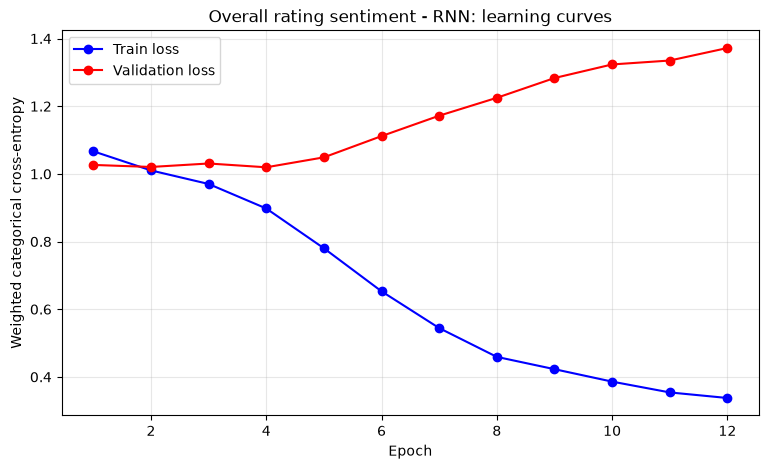


Final test metrics:


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.611004,0.345434,0.31751,0.359766,0.345434,0.544786


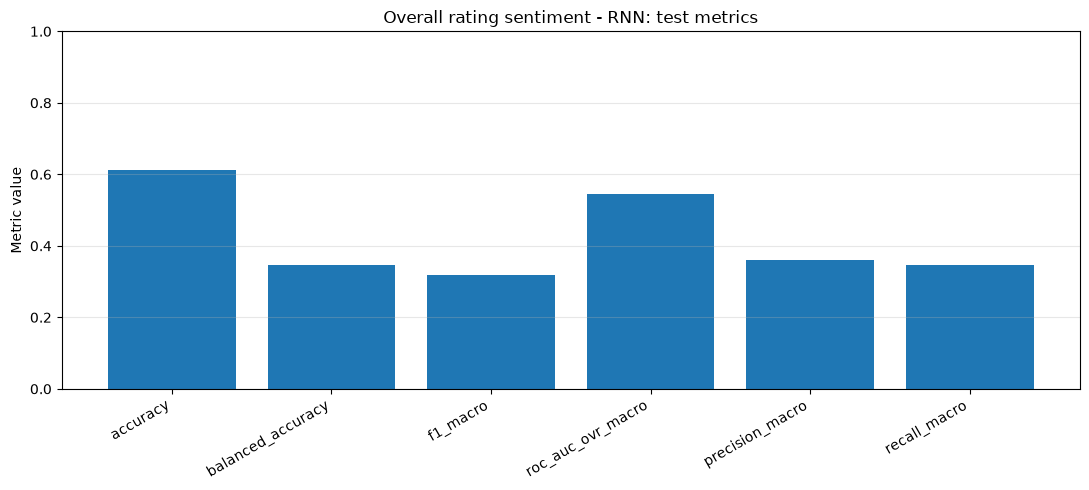

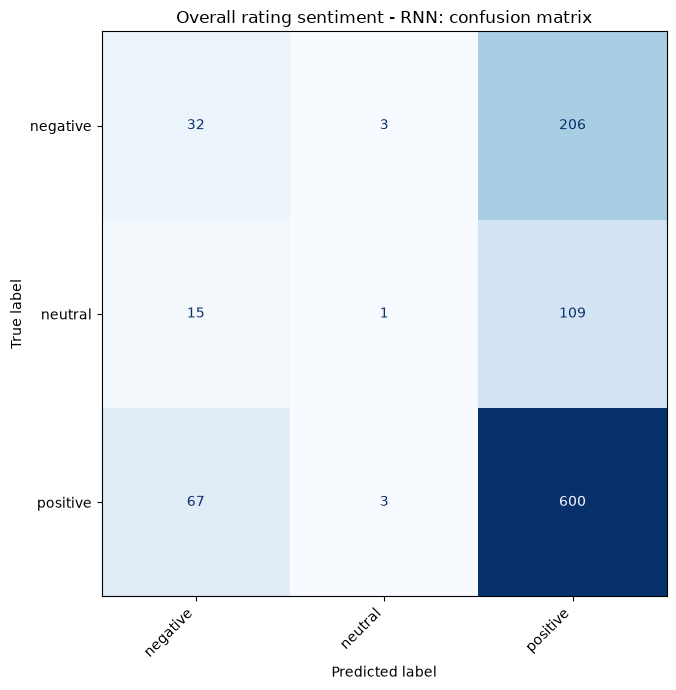

In [108]:
rating_rnn_result = run_experiment(
    experiment_name="Overall rating sentiment - RNN",
    model=rating_rnn,
    X_train=X_rating_fit,
    y_train=y_rating_fit,
    X_val=X_rating_val,
    y_val=y_rating_val,
    X_test=X_rating_test,
    y_test=y_rating_test,
    class_names=rating_class_names,
    training_config=RATING_RNN_CONFIG
)

The vanilla RNN reached its best validation loss of 1.0195 at epoch 4, after which the training loss continued to decrease while the validation loss increased, indicating overfitting. The final accuracy was 0.611004, but the balanced accuracy of 0.345434 and macro F1-score of 0.31751 show poor performance across minority classes. The ROC AUC score of 0.544786 is close to random classification, suggesting that the model mainly benefited from the dominant positive class and failed to learn sufficiently discriminative representations for all sentiment categories. More advanced recurrent architectures such as GRU and LSTM will be evaluated next.

#### GRU

Leaving same embedding & hidden state to compare atchitectures

In [109]:
RATING_GRU_CONFIG = {
    "epochs": 60,
    "batch_size": 16,
    "learning_rate": 3e-4,
    "max_gradient_norm": 5.0,
    "patience": 10,
    "min_delta": 1e-4,
    "lr_patience": 3,
    "lr_factor": 0.5,
    "min_learning_rate": 1e-5
}

In [96]:
rating_gru = SequenceClassifier(
    len(rating_vocabulary),
    RATING_EMBEDDING_DIM,
    RATING_HIDDEN_DIM,
    len(rating_classes),
    "gru",
    2
)

Overall rating sentiment - 2-layer GRU
Train examples: 2485
Validation examples: 622
Test examples: 1036
Trainable parameters: 103,131

Class weights:


,class_name,class_weight
0,negative,0.998889
1,neutral,1.444390
2,positive,0.556721


Epoch 001/60 | train loss: 1.0444 | validation loss: 1.0195 | learning rate: 0.000300
Epoch 002/60 | train loss: 1.0067 | validation loss: 1.0110 | learning rate: 0.000300
Epoch 003/60 | train loss: 0.9607 | validation loss: 0.9978 | learning rate: 0.000300
Epoch 004/60 | train loss: 0.8306 | validation loss: 1.1318 | learning rate: 0.000300
Epoch 005/60 | train loss: 0.6796 | validation loss: 1.3171 | learning rate: 0.000300
Epoch 006/60 | train loss: 0.5426 | validation loss: 1.4788 | learning rate: 0.000300
Epoch 007/60 | train loss: 0.4161 | validation loss: 1.9492 | learning rate: 0.000300
Epoch 008/60 | train loss: 0.3266 | validation loss: 2.0512 | learning rate: 0.000300
Epoch 009/60 | train loss: 0.2573 | validation loss: 2.1788 | learning rate: 0.000300
Epoch 010/60 | train loss: 0.1984 | validation loss: 2.3950 | learning rate: 0.000300
Epoch 011/60 | train loss: 0.1701 | validation loss: 2.4925 | learning rate: 0.000300
Epoch 012/60 | train loss: 0.1355 | validation loss: 2

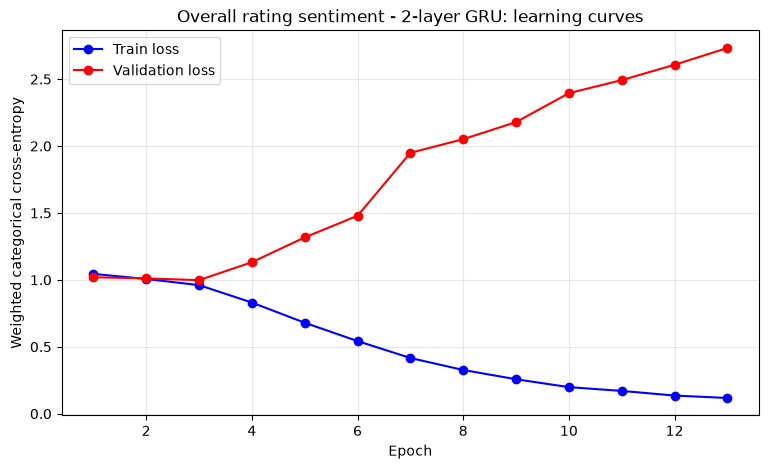


Final test metrics:


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.644788,0.351244,0.310134,0.427969,0.351244,0.629895


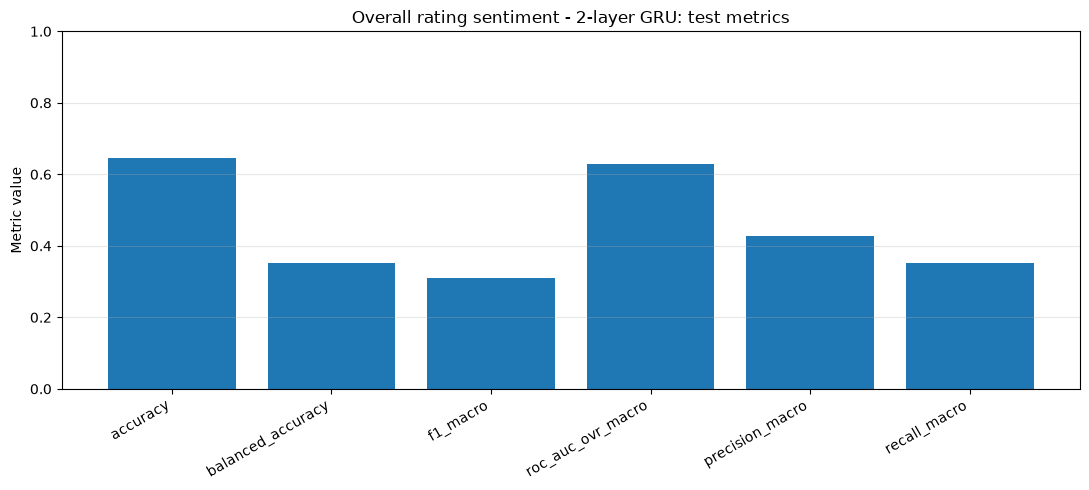

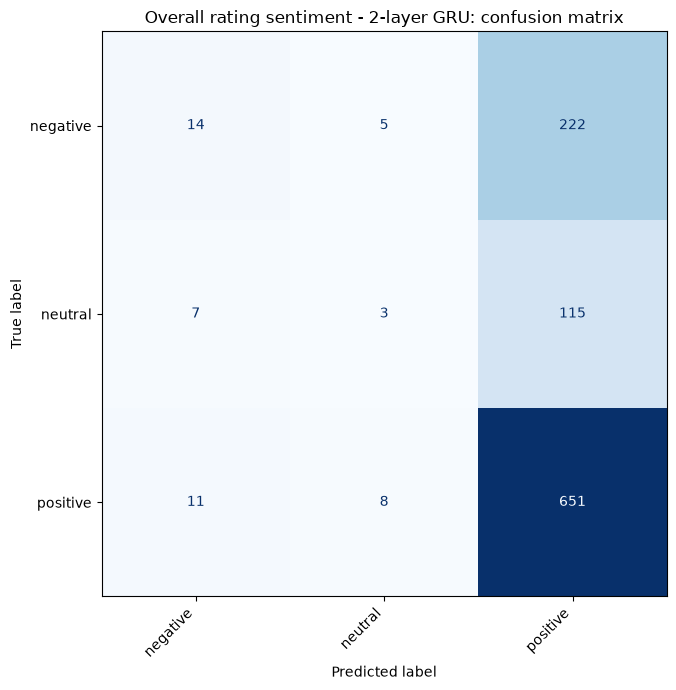

In [97]:
rating_gru_result = run_experiment(
    "Overall rating sentiment - 2-layer GRU",
    rating_gru,
    X_rating_fit, y_rating_fit,
    X_rating_val, y_rating_val,
    X_rating_test, y_rating_test,
    rating_class_names,
    RATING_GRU_CONFIG
)

In [98]:
show_prediction_distribution(
    y_rating_test,
    rating_gru_result["probabilities"],
    rating_class_names
)

,class,true_count,true_percentage,predicted_count,predicted_percentage
0,negative,241,23.262548,32,3.088803
1,neutral,125,12.065637,16,1.544402
2,positive,670,64.671815,988,95.366795


In [99]:
majority_accuracy = np.max(np.bincount(y_rating_test)) / len(y_rating_test)

print(f"Majority-class accuracy: {majority_accuracy:.4f}")
print(f"GRU accuracy: {rating_gru_result['metrics']['accuracy']:.4f}")

Majority-class accuracy: 0.6467
GRU accuracy: 0.6448


In [100]:
from itertools import product

def apply_class_bias(probabilities, class_bias):
    logits = np.log(np.clip(probabilities, 1e-12, 1.0))
    adjusted_logits = logits + class_bias

    return softmax(adjusted_logits)

def tune_class_bias(y_true, probabilities, search_values=None):
    if search_values is None:
        search_values = np.arange(-1.5, 1.51, 0.1)

    number_of_classes = probabilities.shape[1]

    best_score = -np.inf
    best_bias = np.zeros(number_of_classes)

    for bias_values in product(search_values, repeat=number_of_classes - 1):
        class_bias = np.array([*bias_values, 0.0])

        adjusted_probabilities = apply_class_bias(probabilities, class_bias)
        predictions = np.argmax(adjusted_probabilities, axis=1)

        score = f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        )

        if score > best_score:
            best_score = score
            best_bias = class_bias.copy()

    return best_bias, best_score

rating_gru_val_probabilities = predict_probabilities(
    rating_gru,
    X_rating_val
)

rating_gru_bias, rating_gru_val_f1 = tune_class_bias(
    y_rating_val,
    rating_gru_val_probabilities
)

print("Best class bias:", rating_gru_bias)
print("Validation macro F1:", rating_gru_val_f1)

rating_gru_tuned_probabilities = apply_class_bias(
    rating_gru_result["probabilities"],
    rating_gru_bias
)

rating_gru_tuned_metrics, rating_gru_tuned_predictions, rating_gru_tuned_confusion = calculate_metrics(
    y_rating_test,
    rating_gru_tuned_probabilities
)

display(pd.DataFrame([rating_gru_tuned_metrics]))

Best class bias: [0.3 0.3 0. ]
Validation macro F1: 0.4214487811299817


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.627413,0.391396,0.382067,0.422202,0.391396,0.630752


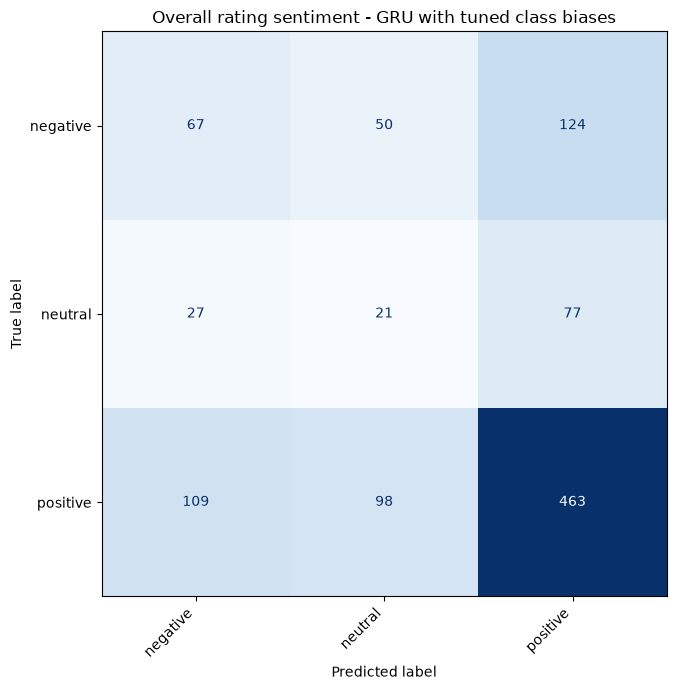

In [62]:
plot_confusion_matrix(
    rating_gru_tuned_confusion,
    rating_class_names,
    "Overall rating sentiment - GRU with tuned class biases"
)

The two-layer GRU achieved its best validation loss at epoch 2. Compared with the vanilla RNN, the GRU produced a macro F1-score of 0.310134 and a balanced accuracy of 0.351244. The gated recurrent architecture slightly improved the classification of minority sentiment classes, but mostly win came still from the biggest class. After changing class biases metrics risen counting for better prediction of majority classes.

#### LSTM

In [110]:
RATING_LSTM_CONFIG = {
    "epochs": 60,
    "batch_size": 16,
    "learning_rate": 3e-4,
    "max_gradient_norm": 5.0,
    "patience": 10,
    "min_delta": 1e-4,
    "lr_patience": 3,
    "lr_factor": 0.5,
    "min_learning_rate": 1e-5
}

In [111]:
rating_lstm = SequenceClassifier(
    len(rating_vocabulary),
    RATING_EMBEDDING_DIM,
    RATING_HIDDEN_DIM,
    len(rating_classes),
    "lstm",
    2
)

Overall rating sentiment - 2-layer LSTM
Train examples: 2485
Validation examples: 622
Test examples: 1036
Trainable parameters: 105,483

Class weights:


,class_name,class_weight
0,negative,0.998889
1,neutral,1.444390
2,positive,0.556721


Epoch 001/60 | train loss: 1.0462 | validation loss: 1.0264 | learning rate: 0.000300
Epoch 002/60 | train loss: 1.0070 | validation loss: 1.0081 | learning rate: 0.000300
Epoch 003/60 | train loss: 0.9385 | validation loss: 1.0908 | learning rate: 0.000300
Epoch 004/60 | train loss: 0.8308 | validation loss: 1.0788 | learning rate: 0.000300
Learning rate reduced: 0.000300 -> 0.000150
Epoch 005/60 | train loss: 0.7311 | validation loss: 1.1915 | learning rate: 0.000150
Epoch 006/60 | train loss: 0.6329 | validation loss: 1.2615 | learning rate: 0.000150
Epoch 007/60 | train loss: 0.5799 | validation loss: 1.3331 | learning rate: 0.000150
Learning rate reduced: 0.000150 -> 0.000075
Epoch 008/60 | train loss: 0.5338 | validation loss: 1.6218 | learning rate: 0.000075
Epoch 009/60 | train loss: 0.4837 | validation loss: 1.6401 | learning rate: 0.000075
Epoch 010/60 | train loss: 0.4543 | validation loss: 1.7485 | learning rate: 0.000075
Learning rate reduced: 0.000075 -> 0.000037
Epoch 01

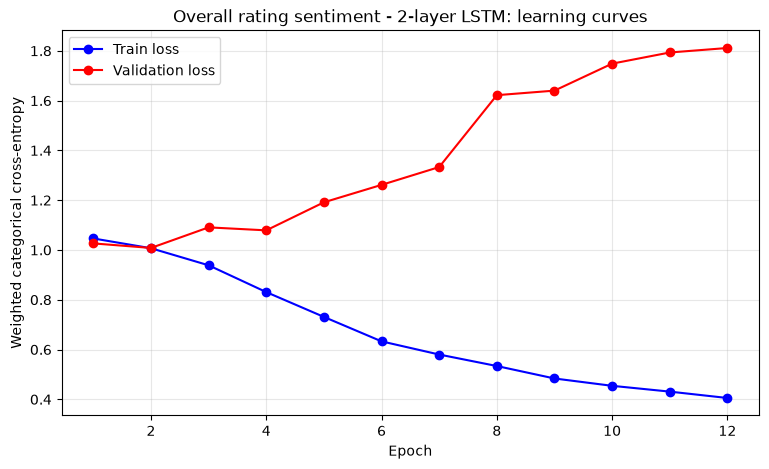


Final test metrics:


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.646718,0.333333,0.261821,0.215573,0.333333,0.615815


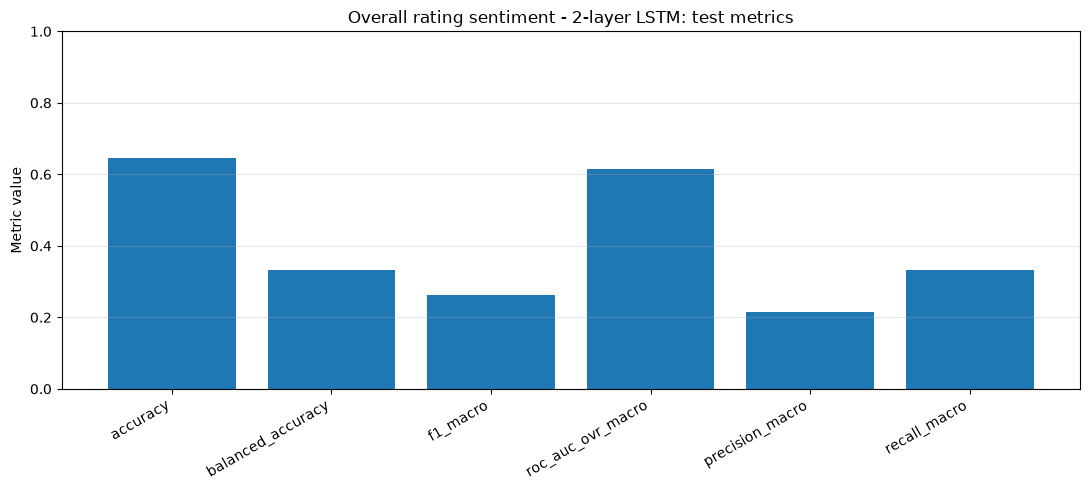

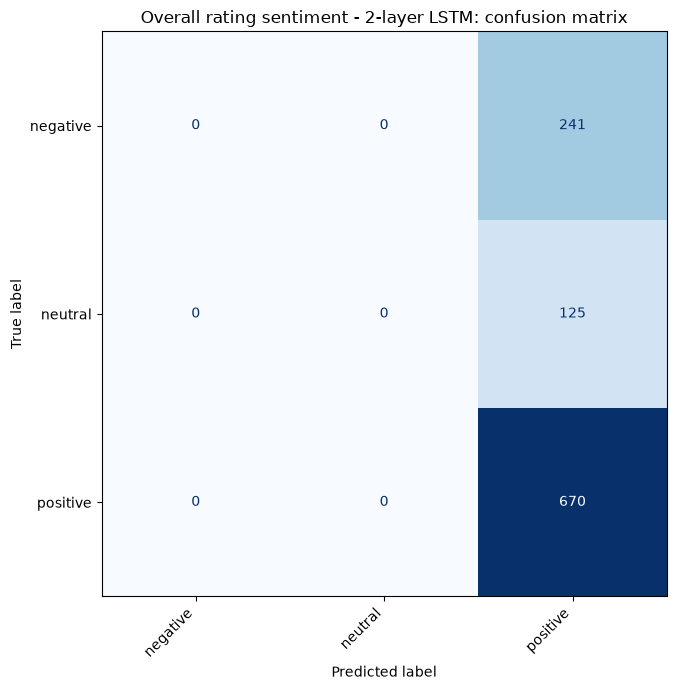

In [112]:
rating_lstm_result = run_experiment(
    "Overall rating sentiment - 2-layer LSTM",
    rating_lstm,
    X_rating_fit, y_rating_fit,
    X_rating_val, y_rating_val,
    X_rating_test, y_rating_test,
    rating_class_names,
    RATING_LSTM_CONFIG
)

In [113]:
rating_lstm_val_probabilities = predict_probabilities(
    rating_lstm,
    X_rating_val
)

rating_lstm_bias, rating_lstm_val_f1 = tune_class_bias(
    y_rating_val,
    rating_lstm_val_probabilities
)

print("Best class bias:", rating_lstm_bias)
print("Validation macro F1:", rating_lstm_val_f1)

rating_lstm_tuned_probabilities = apply_class_bias(
    rating_lstm_result["probabilities"],
    rating_lstm_bias
)

rating_lstm_tuned_metrics, rating_lstm_tuned_predictions, rating_lstm_tuned_confusion = calculate_metrics(
    y_rating_test,
    rating_lstm_tuned_probabilities
)

display(pd.DataFrame([rating_lstm_tuned_metrics]))

Best class bias: [0.5 0.6 0. ]
Validation macro F1: 0.40935181369222806


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.584942,0.40475,0.397619,0.402514,0.40475,0.615952


As we see LSTM predicts only positive classes. With class balancing metrics are slightly higher, but still it is not much better from random guess. 

In [115]:
rating_results = {
    "RNN": rating_rnn_result,
    "2-layer GRU": rating_gru_result,
    "2-layer LSTM": rating_lstm_result
}

rating_comparison = create_comparison_table(rating_results)

display(rating_comparison)

,model,parameters,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,RNN,97251,0.611004,0.345434,0.317510,0.359766,0.345434,0.544786
1,2-layer GRU,103131,0.644788,0.351244,0.310134,0.427969,0.351244,0.629895
2,2-layer LSTM,105483,0.646718,0.333333,0.261821,0.215573,0.333333,0.615815


Overall, we can do a conclusion that for this task RNN and it's inheritence are not the best instances

### Effectiveness prediction models

In [116]:
EFFECTIVENESS_MAX_VOCAB_SIZE = 4_000
EFFECTIVENESS_MAX_SEQUENCE_LENGTH = 80

EFFECTIVENESS_EMBEDDING_DIM = 24
EFFECTIVENESS_HIDDEN_DIM = 24

In [117]:
effectiveness_train_texts = train_df["benefitsReview"].fillna("").astype(str)
effectiveness_test_texts = test_df["benefitsReview"].fillna("").astype(str)

In [118]:
show_text_length_statistics(effectiveness_train_texts)

,Statistic,Number of tokens
0,Minimum,0.00
1,Median,28.00
2,90th percentile,75.00
3,95th percentile,95.00
4,99th percentile,159.76
5,Maximum,392.00


In [119]:
X_effectiveness_train, X_effectiveness_test, effectiveness_vocabulary = prepare_text_data(
    effectiveness_train_texts,
    effectiveness_test_texts,
    EFFECTIVENESS_MAX_SEQUENCE_LENGTH,
    EFFECTIVENESS_MAX_VOCAB_SIZE
)

Vocabulary size: 4000
Train shape: (3107, 80)
Test shape: (1036, 80)


In [120]:
print(train_df["effectiveness"].value_counts())

effectiveness
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: count, dtype: int64


In [121]:
EFFECTIVENESS_ORDER = [
    "Ineffective",
    "Marginally Effective",
    "Moderately Effective",
    "Considerably Effective",
    "Highly Effective"
]

In [124]:
effectiveness_train_labels = train_df["effectiveness"].astype(str).str.strip()
effectiveness_test_labels = test_df["effectiveness"].astype(str).str.strip()

In [125]:
effectiveness_classes, effectiveness_to_id, id_to_effectiveness = create_label_mapping(
    effectiveness_train_labels,
    EFFECTIVENESS_ORDER
)

y_effectiveness_train = encode_labels(effectiveness_train_labels, effectiveness_to_id)
y_effectiveness_test = encode_labels(effectiveness_test_labels, effectiveness_to_id)

effectiveness_class_names = list(effectiveness_classes)

show_class_distribution(
    y_effectiveness_train,
    effectiveness_class_names,
    "Effectiveness train distribution"
)

Effectiveness train distribution


,class_id,class_name,count,percentage
0,0,Ineffective,247,7.949791
1,1,Marginally Effective,187,6.018668
2,2,Moderately Effective,415,13.356936
3,3,Considerably Effective,928,29.868040
4,4,Highly Effective,1330,42.806566


One more time classes are imbalanced

In [126]:
X_effectiveness_fit, X_effectiveness_val, y_effectiveness_fit, y_effectiveness_val = train_test_split(
    X_effectiveness_train,
    y_effectiveness_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_effectiveness_train
)

print("Train:", X_effectiveness_fit.shape)
print("Validation:", X_effectiveness_val.shape)
print("Test:", X_effectiveness_test.shape)

Train: (2485, 80)
Validation: (622, 80)
Test: (1036, 80)


In [127]:
EFFECTIVENESS_RNN_CONFIG = {
    "epochs": 60,
    "batch_size": 16,
    "learning_rate": 3e-4,
    "max_gradient_norm": 5.0,
    "patience": 10,
    "min_delta": 1e-4,
    "lr_patience": 3,
    "lr_factor": 0.5,
    "min_learning_rate": 1e-5
}

In [128]:
effectiveness_rnn = SequenceClassifier(
    len(effectiveness_vocabulary),
    EFFECTIVENESS_EMBEDDING_DIM,
    EFFECTIVENESS_HIDDEN_DIM,
    len(effectiveness_classes),
    "rnn",
    1
)

Effectiveness - RNN
Train examples: 2485
Validation examples: 622
Test examples: 1036
Trainable parameters: 97,301

Class weights:


,class_name,class_weight
0,Ineffective,1.294709
1,Marginally Effective,1.483746
2,Moderately Effective,0.997324
3,Considerably Effective,0.667119
4,Highly Effective,0.557102


Epoch 001/60 | train loss: 1.5735 | validation loss: 1.5493 | learning rate: 0.000300
Epoch 002/60 | train loss: 1.4995 | validation loss: 1.5362 | learning rate: 0.000300
Epoch 003/60 | train loss: 1.4353 | validation loss: 1.4923 | learning rate: 0.000300
Epoch 004/60 | train loss: 1.3286 | validation loss: 1.4553 | learning rate: 0.000300
Epoch 005/60 | train loss: 1.2038 | validation loss: 1.4488 | learning rate: 0.000300
Epoch 006/60 | train loss: 1.0876 | validation loss: 1.4539 | learning rate: 0.000300
Epoch 007/60 | train loss: 0.9614 | validation loss: 1.4971 | learning rate: 0.000300
Learning rate reduced: 0.000300 -> 0.000150
Epoch 008/60 | train loss: 0.8469 | validation loss: 1.5032 | learning rate: 0.000150
Epoch 009/60 | train loss: 0.7365 | validation loss: 1.5807 | learning rate: 0.000150
Epoch 010/60 | train loss: 0.6733 | validation loss: 1.6108 | learning rate: 0.000150
Learning rate reduced: 0.000150 -> 0.000075
Epoch 011/60 | train loss: 0.6171 | validation loss:

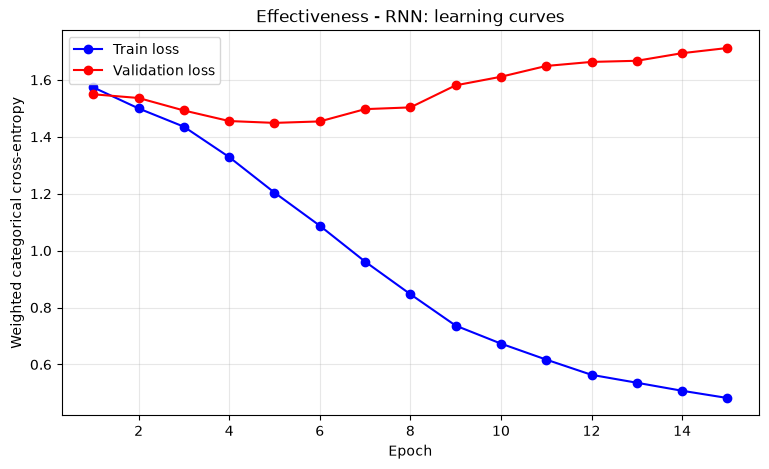


Final test metrics:


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.390927,0.300314,0.28512,0.302204,0.300314,0.623549


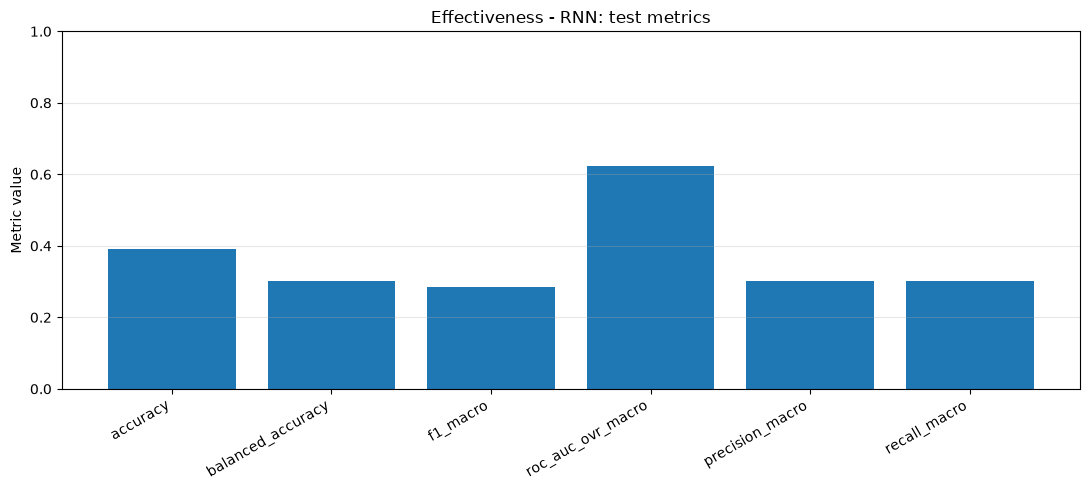

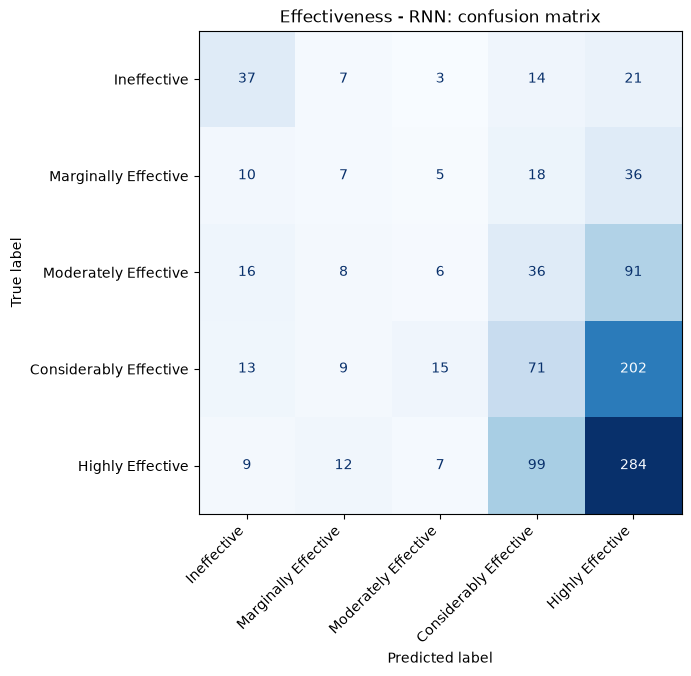

In [129]:
effectiveness_rnn_result = run_experiment(
    "Effectiveness - RNN",
    effectiveness_rnn,
    X_effectiveness_fit, y_effectiveness_fit,
    X_effectiveness_val, y_effectiveness_val,
    X_effectiveness_test, y_effectiveness_test,
    effectiveness_class_names,
    EFFECTIVENESS_RNN_CONFIG
)

Effectiveness - 2-layer GRU
Train examples: 2485
Validation examples: 622
Test examples: 1036
Trainable parameters: 103,181

Class weights:


,class_name,class_weight
0,Ineffective,1.294709
1,Marginally Effective,1.483746
2,Moderately Effective,0.997324
3,Considerably Effective,0.667119
4,Highly Effective,0.557102


Epoch 001/60 | train loss: 1.5870 | validation loss: 1.5534 | learning rate: 0.000300
Epoch 002/60 | train loss: 1.5182 | validation loss: 1.5198 | learning rate: 0.000300
Epoch 003/60 | train loss: 1.4839 | validation loss: 1.4940 | learning rate: 0.000300
Epoch 004/60 | train loss: 1.4114 | validation loss: 1.4316 | learning rate: 0.000300
Epoch 005/60 | train loss: 1.2872 | validation loss: 1.4385 | learning rate: 0.000300
Epoch 006/60 | train loss: 1.1726 | validation loss: 1.5041 | learning rate: 0.000300
Learning rate reduced: 0.000300 -> 0.000150
Epoch 007/60 | train loss: 1.0632 | validation loss: 1.5476 | learning rate: 0.000150
Epoch 008/60 | train loss: 0.9607 | validation loss: 1.5975 | learning rate: 0.000150
Epoch 009/60 | train loss: 0.8981 | validation loss: 1.6500 | learning rate: 0.000150
Learning rate reduced: 0.000150 -> 0.000075
Epoch 010/60 | train loss: 0.8459 | validation loss: 1.6670 | learning rate: 0.000075
Epoch 011/60 | train loss: 0.7991 | validation loss:

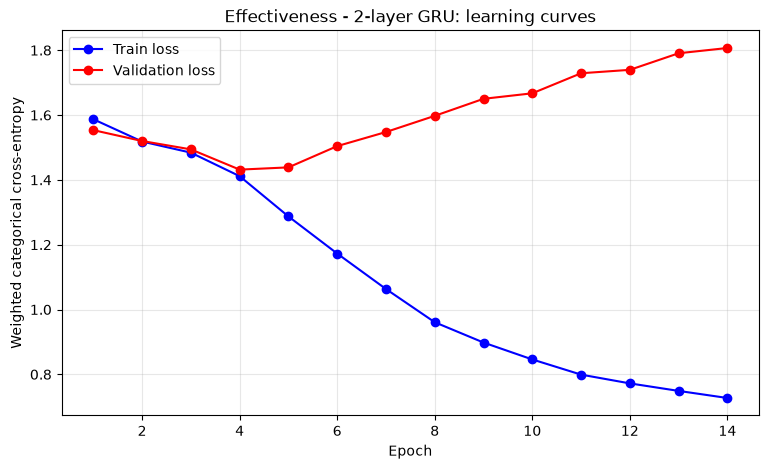


Final test metrics:


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.420849,0.270483,0.264268,0.374927,0.270483,0.668645


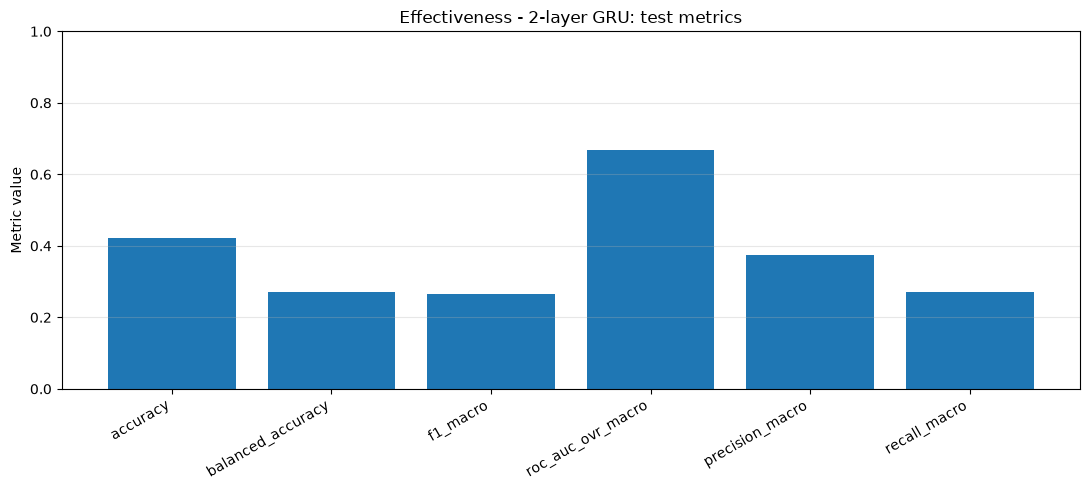

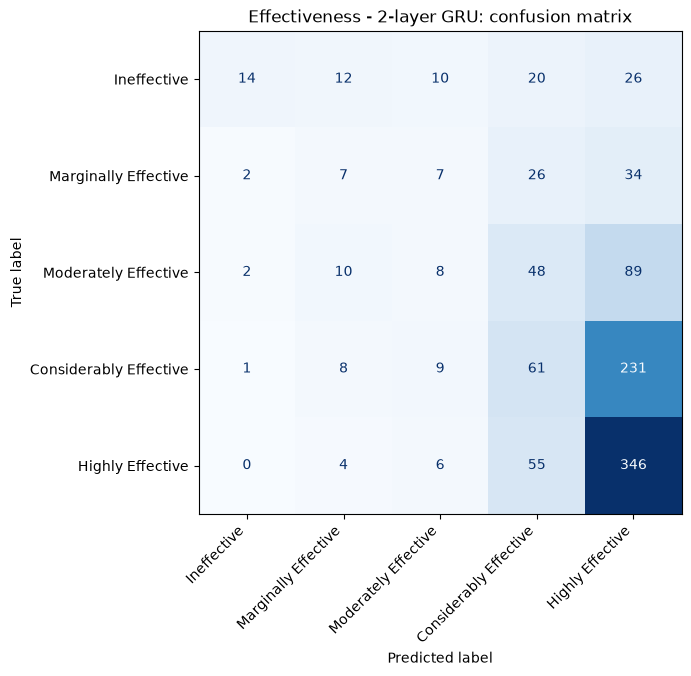

In [130]:
EFFECTIVENESS_GRU_CONFIG = {
    "epochs": 60,
    "batch_size": 32,
    "learning_rate": 3e-4,
    "max_gradient_norm": 5.0,
    "patience": 10,
    "min_delta": 1e-4,
    "lr_patience": 3,
    "lr_factor": 0.5,
    "min_learning_rate": 1e-5
}

effectiveness_gru = SequenceClassifier(
    len(effectiveness_vocabulary),
    EFFECTIVENESS_EMBEDDING_DIM,
    EFFECTIVENESS_HIDDEN_DIM,
    len(effectiveness_classes),
    "gru",
    2
)

effectiveness_gru_result = run_experiment(
    "Effectiveness - 2-layer GRU",
    effectiveness_gru,
    X_effectiveness_fit, y_effectiveness_fit,
    X_effectiveness_val, y_effectiveness_val,
    X_effectiveness_test, y_effectiveness_test,
    effectiveness_class_names,
    EFFECTIVENESS_GRU_CONFIG
)

Effectiveness - 2-layer LSTM
Train examples: 2485
Validation examples: 622
Test examples: 1036
Trainable parameters: 105,533

Class weights:


,class_name,class_weight
0,Ineffective,1.294709
1,Marginally Effective,1.483746
2,Moderately Effective,0.997324
3,Considerably Effective,0.667119
4,Highly Effective,0.557102


Epoch 001/60 | train loss: 1.5637 | validation loss: 1.5283 | learning rate: 0.000300
Epoch 002/60 | train loss: 1.5067 | validation loss: 1.5027 | learning rate: 0.000300
Epoch 003/60 | train loss: 1.4357 | validation loss: 1.4370 | learning rate: 0.000300
Epoch 004/60 | train loss: 1.3387 | validation loss: 1.4238 | learning rate: 0.000300
Epoch 005/60 | train loss: 1.2668 | validation loss: 1.4345 | learning rate: 0.000300
Epoch 006/60 | train loss: 1.1933 | validation loss: 1.4782 | learning rate: 0.000300
Learning rate reduced: 0.000300 -> 0.000150
Epoch 007/60 | train loss: 1.1322 | validation loss: 1.5049 | learning rate: 0.000150
Epoch 008/60 | train loss: 1.0528 | validation loss: 1.5305 | learning rate: 0.000150
Epoch 009/60 | train loss: 1.0059 | validation loss: 1.5578 | learning rate: 0.000150
Learning rate reduced: 0.000150 -> 0.000075
Epoch 010/60 | train loss: 0.9633 | validation loss: 1.5891 | learning rate: 0.000075
Epoch 011/60 | train loss: 0.9199 | validation loss:

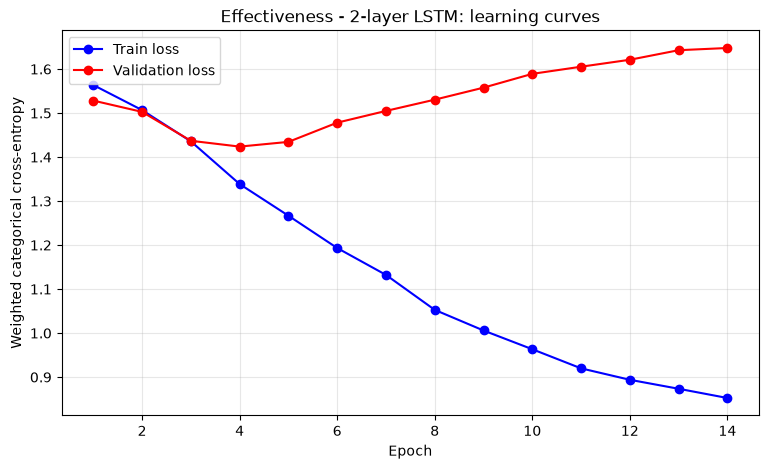


Final test metrics:


,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,0.407336,0.261143,0.230174,0.263961,0.261143,0.668962


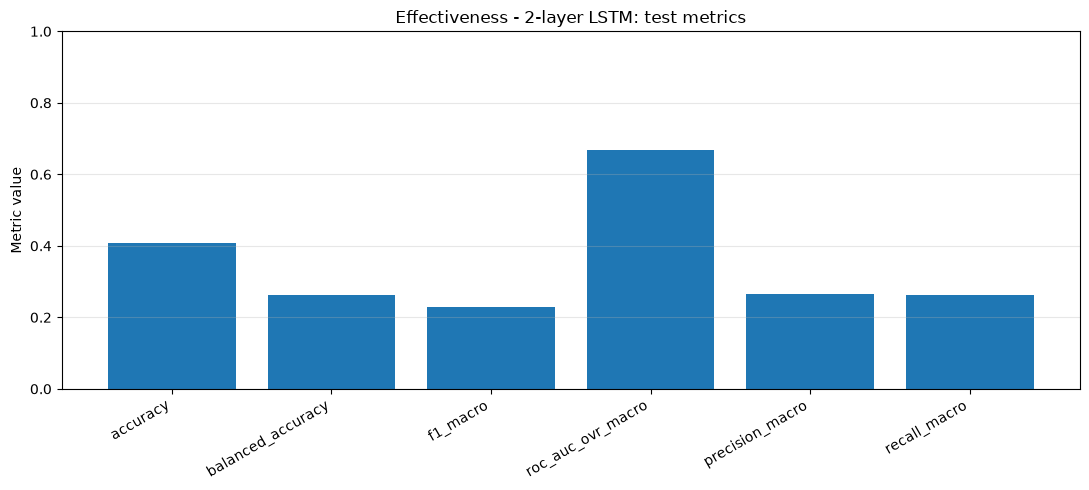

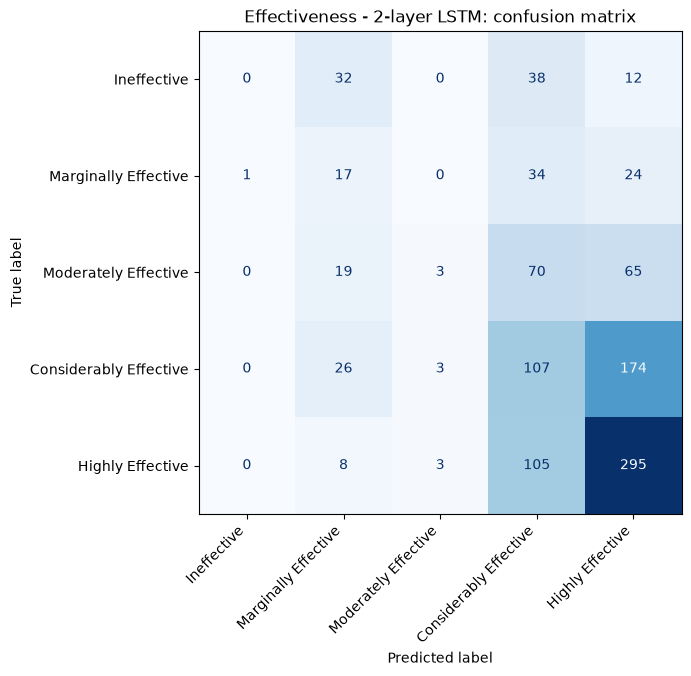

In [131]:
EFFECTIVENESS_LSTM_CONFIG = {
    "epochs": 60,
    "batch_size": 32,
    "learning_rate": 3e-4,
    "max_gradient_norm": 5.0,
    "patience": 10,
    "min_delta": 1e-4,
    "lr_patience": 3,
    "lr_factor": 0.5,
    "min_learning_rate": 1e-5
}

effectiveness_lstm = SequenceClassifier(
    len(effectiveness_vocabulary),
    EFFECTIVENESS_EMBEDDING_DIM,
    EFFECTIVENESS_HIDDEN_DIM,
    len(effectiveness_classes),
    "lstm",
    2
)

effectiveness_lstm_result = run_experiment(
    "Effectiveness - 2-layer LSTM",
    effectiveness_lstm,
    X_effectiveness_fit, y_effectiveness_fit,
    X_effectiveness_val, y_effectiveness_val,
    X_effectiveness_test, y_effectiveness_test,
    effectiveness_class_names,
    EFFECTIVENESS_LSTM_CONFIG
)

In [132]:
effectiveness_results = {
    "RNN": effectiveness_rnn_result,
    "2-layer GRU": effectiveness_gru_result,
    "2-layer LSTM": effectiveness_lstm_result
}

effectiveness_comparison = create_comparison_table(effectiveness_results)

display(effectiveness_comparison)

,model,parameters,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro
0,RNN,97301,0.390927,0.300314,0.285120,0.302204,0.300314,0.623549
1,2-layer GRU,103181,0.420849,0.270483,0.264268,0.374927,0.270483,0.668645
2,2-layer LSTM,105533,0.407336,0.261143,0.230174,0.263961,0.261143,0.668962


### Effectiveness model comparison

Here we see the same as we saw for ratings models. High imbalance to positive classes, RNN here perform as least biased models, and overall models are ineffective